In [142]:
import random
import matplotlib.pyplot as plt 
from picograd.engine import Value

In [98]:
# Neuron
class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0
    

class Neuron(Module):
    def __init__(self, nin, activation='relu'):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(0.0)
        assert activation in ('relu', 'tanh', None), "activation must be 'relu', 'tanh', or None"
        self.activation = activation
        
    def __call__(self, x):
        #w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        
        if self.activation == 'relu':
            return act.relu()
        elif self.activation == 'tanh':
            return act.tanh()
        else:
            return act
        
    def parameters(self):
        return self.w + [self.b]
    
    def __repr__(self):
        act = self.activation or 'linear'
        return f"Neuron(in={len(self.w)}, act={act})"

    
x = [2.0, 3.0]
n = Neuron(2)
print(n.w, n.b)
print(n(x))
print(n.parameters())
print(n)
        
    

[Value(data=0.9379925145695025), Value(data=0.8527339660162552)] Value(data=0.0)
Value(data=4.4341869271877705)
[Value(data=0.9379925145695025), Value(data=0.8527339660162552), Value(data=0.0)]
Neuron(in=2, act=relu)


In [61]:
class Layer(Module):
    def __init__(self, nin, nout, **kwargs):
        self.nin = nin
        self.nout = nout
        self.activation = kwargs.get('activation', 'relu')
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]        
        return outs[0] if len(outs) == 1 else outs 
    
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]
    
    def __repr__(self):
        return f"Layer(in={self.nin}, out={self.nout}, act={self.activation})"
        
x = [2.0, 3.0, -2.0]
n = Layer(3, 5)
print(n(x))
len(n.parameters()) #3 * 5 + 5
print(n)


[Value(data=2.0278387251835333), Value(data=2.8336328441144993), Value(data=0), Value(data=1.2326110094410234), Value(data=0)]
Layer(in=3, out=5, act=relu)


In [99]:
class MLP(Module):
    def __init__(self, nin, nouts:list, **kwargs):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], **kwargs) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x 
    
    def parameters(self):
        out = [p for layer in self.layers for p in layer.parameters()]
        return out 
    
    def __repr__(self):
        rows = "\n".join(f"  ({i}): {layer}" for i, layer in enumerate(self.layers))
        return f"MLP(\n{rows}\n)"

x = [2.0, 3.0, -2.0]
n = MLP(3, [5, 5, 1], activation = 'tanh')  
n    
    

MLP(
  (0): Layer(in=3, out=5, act=tanh)
  (1): Layer(in=5, out=5, act=tanh)
  (2): Layer(in=5, out=1, act=tanh)
)

In [ ]:


def make_data(n, seed=42):
    random.seed(seed)
    xs, ys = [], []
    for _ in range(n):
        x1 = random.uniform(-2, 2)
        x2 = random.uniform(-2, 2)
        label = 1.0 if (x1**2 + x2**2) < 1.0 else -1.0 
        xs.append([x1, x2])
        ys.append(label)
    return xs, ys

xs, ys = make_data(100)
len(xs), len(xs[0]), len(ys)

(100, 2, 100)

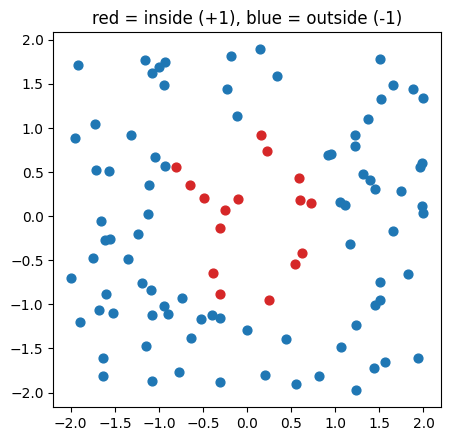

In [78]:
def plot(xs, ys, title='red = inside (+1), blue = outside (-1)'):
    plt.figure(figsize=(5, 5))
    plt.gca().set_aspect('equal')
    plt.title(title)
    for (x1,x2), y in zip(xs, ys):
        plt.scatter(x1, x2, c='tab:red' if y > 0 else 'tab:blue', s=40)
    
plot(xs, ys)

In [138]:
xs, ys = make_data(100)
n = MLP(2, [5,5,1], activation='tanh')
lr = 0.01 

def cal_mse(ys:list, ypred:list) -> float:
    return sum([(yi - ypredi)**2 for yi, ypredi in zip(ys, ypred)], Value(0.0)) / len(ys)

ypred = [n(x) for x in xs]
loss = cal_mse(ys, ypred)
loss
    

Value(data=1.0309915351272962)

In [110]:
len(n.parameters())

51

In [126]:
ypred = [n(x) for x in xs]
loss = cal_mse(ys, ypred)
print(loss)

Value(data=62.22528882615163)


In [123]:
n.zero_grad()

In [124]:
loss.backward()

In [125]:
for p in n.parameters():
    p.data -= lr*p.grad


In [140]:
xs, ys = make_data(100)
n = MLP(2, [5, 5, 1], activation='tanh')
lr = 0.1

for epoch in range(150):
    #forward
    ypred = [n(x) for x in xs]
    loss = cal_mse(ys, ypred)
    
    n.zero_grad()
    
    #backward
    loss.backward()
    
    #update
    for p in n.parameters():
        p.data -= lr * p.grad
    
    print(f"step {epoch:2d}  loss {loss.data:.4f}")

step  0  loss 1.0310
step  1  loss 0.8040
step  2  loss 0.6902
step  3  loss 0.6386
step  4  loss 0.6121
step  5  loss 0.5965
step  6  loss 0.5864
step  7  loss 0.5794
step  8  loss 0.5741
step  9  loss 0.5700
step 10  loss 0.5666
step 11  loss 0.5637
step 12  loss 0.5612
step 13  loss 0.5589
step 14  loss 0.5568
step 15  loss 0.5547
step 16  loss 0.5528
step 17  loss 0.5509
step 18  loss 0.5491
step 19  loss 0.5473
step 20  loss 0.5454
step 21  loss 0.5436
step 22  loss 0.5418
step 23  loss 0.5399
step 24  loss 0.5380
step 25  loss 0.5361
step 26  loss 0.5342
step 27  loss 0.5322
step 28  loss 0.5302
step 29  loss 0.5282
step 30  loss 0.5261
step 31  loss 0.5240
step 32  loss 0.5218
step 33  loss 0.5196
step 34  loss 0.5173
step 35  loss 0.5150
step 36  loss 0.5126
step 37  loss 0.5102
step 38  loss 0.5077
step 39  loss 0.5052
step 40  loss 0.5026
step 41  loss 0.5000
step 42  loss 0.4973
step 43  loss 0.4945
step 44  loss 0.4917
step 45  loss 0.4888
step 46  loss 0.4859
step 47  loss

In [136]:
import numpy as np   

def plot_decision_boundary(model, xs, ys, resolution=40):
    lin = np.linspace(-2, 2, resolution)
    xx, yy = np.meshgrid(lin, lin)

    Z = np.zeros_like(xx)
    for i in range(resolution):
        for j in range(resolution):
            out = model([float(xx[i, j]), float(yy[i, j])])
            Z[i, j] = out.data

    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, Z, levels=[-100, 0, 100],
                 colors=['tab:blue', 'tab:red'], alpha=0.25)
    plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=1)  # 学到的边界

    for (x1, x2), y in zip(xs, ys):
        plt.scatter(x1, x2, c='tab:red' if y > 0 else 'tab:blue',
                    s=40, edgecolors='k', linewidths=0.5)

    plt.gca().set_aspect('equal')
    plt.title('learned decision boundary')
    plt.xlabel('x1'); plt.ylabel('x2')
    plt.show()

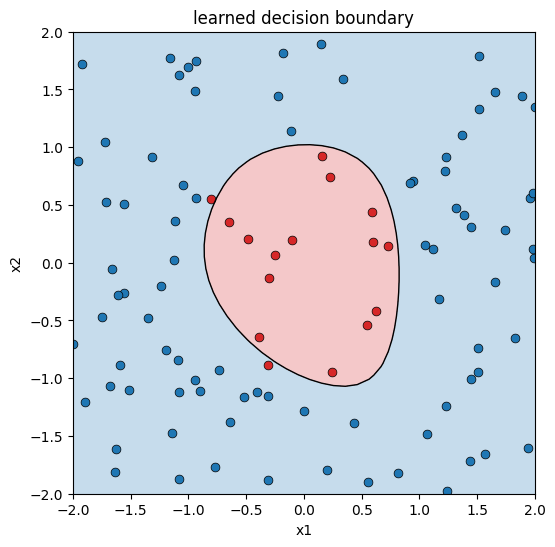

In [141]:
plot_decision_boundary(n, xs, ys)